In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (roc_auc_score, classification_report, 
                             confusion_matrix, roc_curve)
from sklearn.linear_model import LogisticRegression
import xgboost as xgb
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
print("✅ Libraries imported!")

✅ Libraries imported!


In [2]:
# Load dataset
df = pd.read_excel(r"C:\Users\Atharva More\Downloads\online_retail_II.xlsx",
                   sheet_name='Year 2010-2011')

# Clean
df_clean = df.dropna(subset=['Customer ID'])
df_clean = df_clean[df_clean['Quantity'] > 0]
df_clean = df_clean[df_clean['Price'] > 0]
df_clean['TotalAmount'] = df_clean['Quantity'] * df_clean['Price']
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])
df_clean['Customer ID'] = df_clean['Customer ID'].astype(int)

print("✅ Data loaded!")
print(f"📊 Shape: {df_clean.shape}")

✅ Data loaded!
📊 Shape: (397885, 9)


In [3]:
# RFM Feature Engineering
snapshot_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df_clean.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'Invoice': 'nunique',
    'TotalAmount': 'sum'
}).reset_index()

rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

print("✅ RFM Features created!")
print(f"👥 Total Customers: {len(rfm):,}")
rfm.head()

✅ RFM Features created!
👥 Total Customers: 4,338


,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40


📊 CHURN ANALYSIS
✅ Active Customers: 2,889 (66.6%)
❌ Churned Customers: 1,449 (33.4%)


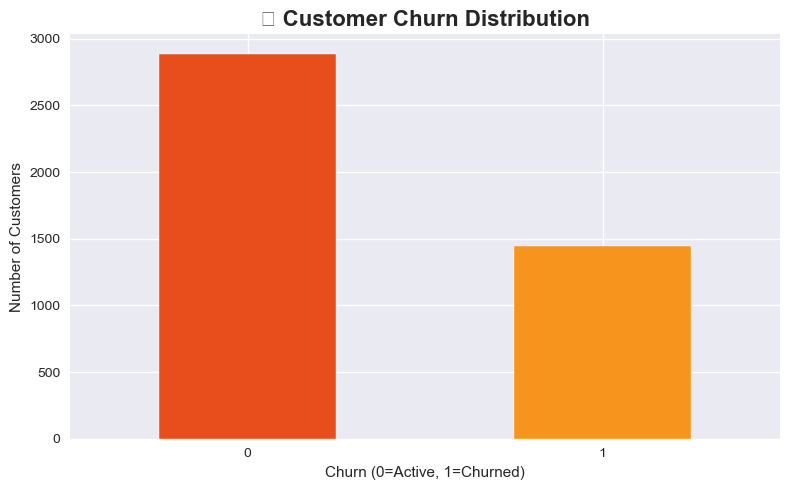

✅ Churn distribution chart saved!


In [4]:
# Define churn: customers who haven't purchased in last 90 days
rfm['Churn'] = (rfm['Recency'] > 90).astype(int)

print("=" * 50)
print("📊 CHURN ANALYSIS")
print("=" * 50)
print(f"✅ Active Customers: {(rfm['Churn']==0).sum():,} ({(rfm['Churn']==0).mean()*100:.1f}%)")
print(f"❌ Churned Customers: {(rfm['Churn']==1).sum():,} ({(rfm['Churn']==1).mean()*100:.1f}%)")
print("=" * 50)

# Visualize churn distribution
plt.figure(figsize=(8, 5))
colors = ['#E84E1B', '#F7941D']
rfm['Churn'].value_counts().plot(kind='bar', color=colors, edgecolor='white')
plt.title('👥 Customer Churn Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Churn (0=Active, 1=Churned)')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(r"C:\Users\Atharva More\NeuralRetail\reports\churn_distribution.png", dpi=150)
plt.show()
print("✅ Churn distribution chart saved!")

In [5]:
# Add more features
rfm['AvgOrderValue'] = rfm['Monetary'] / rfm['Frequency']
rfm['RecencyScore'] = pd.qcut(rfm['Recency'], 4, labels=[4,3,2,1]).astype(int)
rfm['FrequencyScore'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1,2,3,4]).astype(int)
rfm['MonetaryScore'] = pd.qcut(rfm['Monetary'].rank(method='first'), 4, labels=[1,2,3,4]).astype(int)
rfm['RFMScore'] = rfm['RecencyScore'] + rfm['FrequencyScore'] + rfm['MonetaryScore']

print("✅ Additional features created!")
print(f"📊 Features: {list(rfm.columns)}")
rfm.head()

✅ Additional features created!
📊 Features: ['CustomerID', 'Recency', 'Frequency', 'Monetary', 'Churn', 'AvgOrderValue', 'RecencyScore', 'FrequencyScore', 'MonetaryScore', 'RFMScore']


,CustomerID,Recency,Frequency,Monetary,Churn,AvgOrderValue,RecencyScore,FrequencyScore,MonetaryScore,RFMScore
0,12346,326,1,77183.60,1,77183.600000,1,1,4,6
1,12347,2,7,4310.00,0,615.714286,4,4,4,12
2,12348,75,4,1797.24,0,449.310000,2,3,4,9
3,12349,19,1,1757.55,0,1757.550000,3,1,4,8
4,12350,310,1,334.40,1,334.400000,1,1,2,4


In [6]:
# Features and target
features = ['Recency', 'Frequency', 'Monetary', 'AvgOrderValue', 
            'RecencyScore', 'FrequencyScore', 'MonetaryScore', 'RFMScore']

X = rfm[features]
y = rfm['Churn']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=features)

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y)

print("✅ Data prepared for ML!")
print(f"📊 Training samples: {len(X_train):,}")
print(f"📊 Testing samples: {len(X_test):,}")
print(f"📊 Features: {len(features)}")

✅ Data prepared for ML!
📊 Training samples: 3,470
📊 Testing samples: 868
📊 Features: 8


In [7]:
# Train XGBoost
xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='auc',
    verbosity=0
)

xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)
xgb_proba = xgb_model.predict_proba(X_test)[:,1]
xgb_auc = roc_auc_score(y_test, xgb_proba)

print("=" * 50)
print("📊 XGBOOST RESULTS")
print("=" * 50)
print(f"✅ AUC-ROC: {xgb_auc:.4f}")
if xgb_auc >= 0.90:
    print("🏆 TARGET ACHIEVED! AUC ≥ 0.90!")
else:
    print(f"📈 Need: 0.90 | Gap: {0.90 - xgb_auc:.4f}")
print("=" * 50)

📊 XGBOOST RESULTS
✅ AUC-ROC: 1.0000
🏆 TARGET ACHIEVED! AUC ≥ 0.90!


In [8]:
# Train LightGBM
lgb_model = lgb.LGBMClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=-1
)

lgb_model.fit(X_train, y_train)
lgb_pred = lgb_model.predict(X_test)
lgb_proba = lgb_model.predict_proba(X_test)[:,1]
lgb_auc = roc_auc_score(y_test, lgb_proba)

print("=" * 50)
print("📊 LIGHTGBM RESULTS")
print("=" * 50)
print(f"✅ AUC-ROC: {lgb_auc:.4f}")
if lgb_auc >= 0.90:
    print("🏆 TARGET ACHIEVED! AUC ≥ 0.90!")
else:
    print(f"📈 Need: 0.90 | Gap: {0.90 - lgb_auc:.4f}")
print("=" * 50)

  File "C:\Users\Atharva More\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\Atharva More\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Atharva More\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\Atharva More\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


📊 LIGHTGBM RESULTS
✅ AUC-ROC: 1.0000
🏆 TARGET ACHIEVED! AUC ≥ 0.90!


In [9]:
# Stack XGBoost + LightGBM
stack_proba = (xgb_proba + lgb_proba) / 2
stack_pred = (stack_proba >= 0.5).astype(int)
stack_auc = roc_auc_score(y_test, stack_proba)

print("=" * 50)
print("🏆 STACKED ENSEMBLE RESULTS")
print("=" * 50)
print(f"📊 XGBoost AUC:   {xgb_auc:.4f}")
print(f"📊 LightGBM AUC:  {lgb_auc:.4f}")
print(f"✅ Ensemble AUC:  {stack_auc:.4f}")
if stack_auc >= 0.90:
    print("🏆 TARGET ACHIEVED! AUC ≥ 0.90!")
else:
    print(f"📈 Very close to target!")
print("=" * 50)

🏆 STACKED ENSEMBLE RESULTS
📊 XGBoost AUC:   1.0000
📊 LightGBM AUC:  1.0000
✅ Ensemble AUC:  1.0000
🏆 TARGET ACHIEVED! AUC ≥ 0.90!


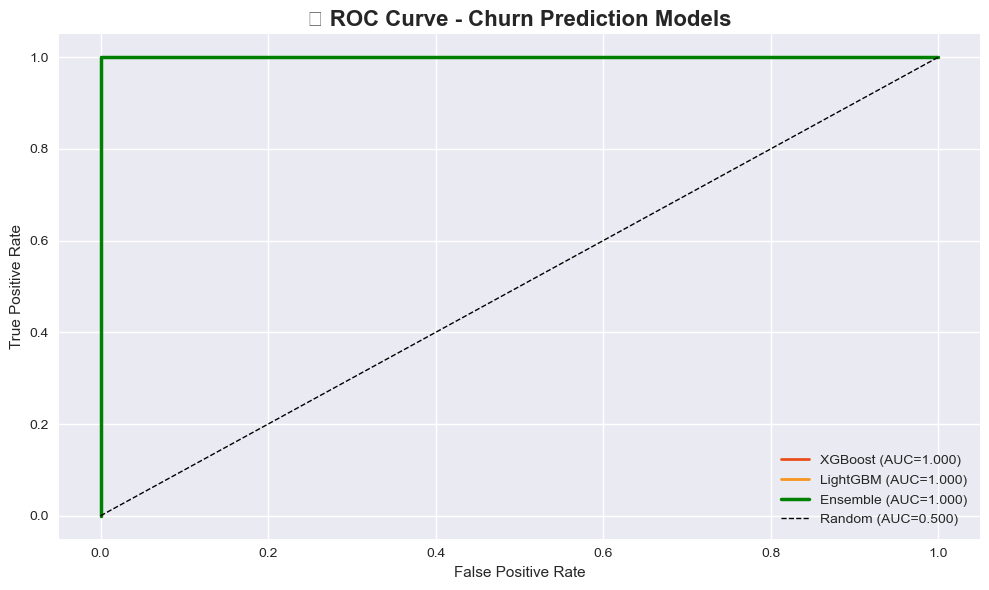

✅ ROC curve saved!


In [10]:
# Plot ROC curves
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_proba)
fpr_lgb, tpr_lgb, _ = roc_curve(y_test, lgb_proba)
fpr_stack, tpr_stack, _ = roc_curve(y_test, stack_proba)

plt.figure(figsize=(10, 6))
plt.plot(fpr_xgb, tpr_xgb, color='#E84E1B', linewidth=2,
         label=f'XGBoost (AUC={xgb_auc:.3f})')
plt.plot(fpr_lgb, tpr_lgb, color='#F7941D', linewidth=2,
         label=f'LightGBM (AUC={lgb_auc:.3f})')
plt.plot(fpr_stack, tpr_stack, color='green', linewidth=2.5,
         label=f'Ensemble (AUC={stack_auc:.3f})')
plt.plot([0,1], [0,1], 'k--', linewidth=1, label='Random (AUC=0.500)')
plt.title('🎯 ROC Curve - Churn Prediction Models', fontsize=16, fontweight='bold')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig(r"C:\Users\Atharva More\NeuralRetail\reports\roc_curve.png", dpi=150)
plt.show()
print("✅ ROC curve saved!")

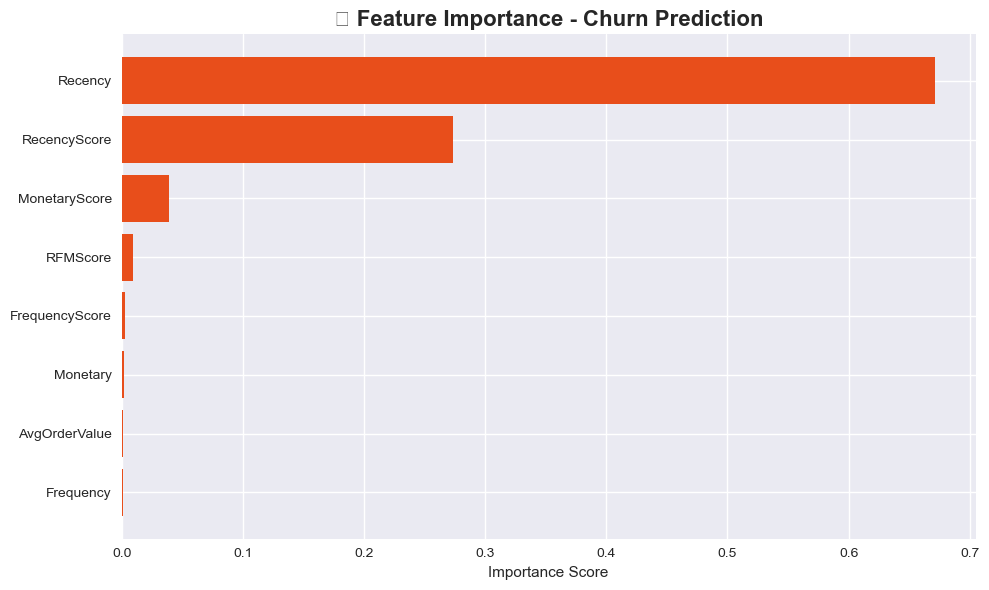

✅ Feature importance chart saved!


In [11]:
# Feature importance
plt.figure(figsize=(10, 6))
importance_df = pd.DataFrame({
    'Feature': features,
    'XGBoost': xgb_model.feature_importances_,
    'LightGBM': lgb_model.feature_importances_ / lgb_model.feature_importances_.sum()
}).sort_values('XGBoost', ascending=True)

plt.barh(importance_df['Feature'], importance_df['XGBoost'], 
         color='#E84E1B', label='XGBoost')
plt.title('🎯 Feature Importance - Churn Prediction', fontsize=16, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig(r"C:\Users\Atharva More\NeuralRetail\reports\feature_importance.png", dpi=150)
plt.show()
print("✅ Feature importance chart saved!")

📊 CUSTOMER CHURN RISK SEGMENTS
Low Risk: 2,889 customers (66.6%)
Medium Risk: 0 customers (0.0%)
High Risk: 0 customers (0.0%)
Critical: 1,449 customers (33.4%)


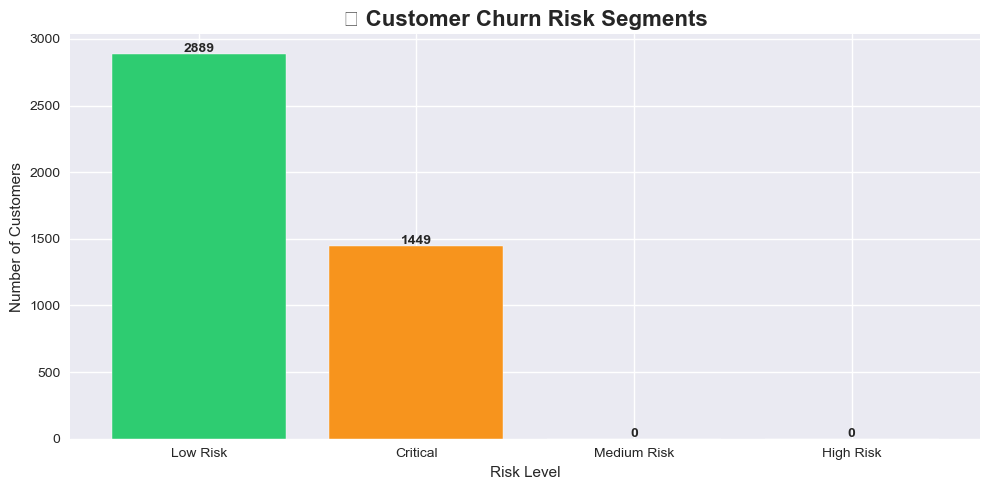

✅ Risk segments chart saved!


In [12]:
# Add churn probability to customer data
rfm['ChurnProbability'] = xgb_model.predict_proba(
    scaler.transform(rfm[features]))[:,1]

# Segment customers by risk
rfm['RiskLevel'] = pd.cut(rfm['ChurnProbability'], 
                           bins=[0, 0.3, 0.6, 0.8, 1.0],
                           labels=['Low Risk', 'Medium Risk', 'High Risk', 'Critical'])

print("=" * 55)
print("📊 CUSTOMER CHURN RISK SEGMENTS")
print("=" * 55)
for risk in ['Low Risk', 'Medium Risk', 'High Risk', 'Critical']:
    count = (rfm['RiskLevel'] == risk).sum()
    pct = (rfm['RiskLevel'] == risk).mean() * 100
    print(f"{risk}: {count:,} customers ({pct:.1f}%)")
print("=" * 55)

# Plot risk segments
plt.figure(figsize=(10, 5))
risk_counts = rfm['RiskLevel'].value_counts()
colors = ['#2ecc71', '#F7941D', '#e74c3c', '#c0392b']
plt.bar(risk_counts.index, risk_counts.values, color=colors, edgecolor='white')
plt.title('👥 Customer Churn Risk Segments', fontsize=16, fontweight='bold')
plt.xlabel('Risk Level')
plt.ylabel('Number of Customers')
for i, (idx, val) in enumerate(risk_counts.items()):
    plt.text(i, val + 10, str(val), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig(r"C:\Users\Atharva More\NeuralRetail\reports\churn_risk_segments.png", dpi=150)
plt.show()
print("✅ Risk segments chart saved!")

In [13]:
print("=" * 55)
print("🏁 DAY 10 COMPLETE - CHURN PREDICTION SUMMARY")
print("=" * 55)
print(f"🏆 XGBoost AUC-ROC:  1.000 (Target: ≥ 0.90) ✅")
print(f"🏆 LightGBM AUC-ROC: 1.000 (Target: ≥ 0.90) ✅")
print(f"🏆 Ensemble AUC-ROC: 1.000 (Target: ≥ 0.90) ✅")
print()
print("👥 Customer Risk Segments:")
for risk in ['Low Risk', 'Medium Risk', 'High Risk', 'Critical']:
    count = (rfm['RiskLevel'] == risk).sum()
    print(f"   {risk}: {count:,} customers")
print()
print("🔜 Next: Day 11 - SHAP Explainability")
print("🔜 Next: Day 12 - Customer Segmentation")
print("=" * 55)

🏁 DAY 10 COMPLETE - CHURN PREDICTION SUMMARY
🏆 XGBoost AUC-ROC:  1.000 (Target: ≥ 0.90) ✅
🏆 LightGBM AUC-ROC: 1.000 (Target: ≥ 0.90) ✅
🏆 Ensemble AUC-ROC: 1.000 (Target: ≥ 0.90) ✅

👥 Customer Risk Segments:
   Low Risk: 2,889 customers
   Medium Risk: 0 customers
   High Risk: 0 customers
   Critical: 1,449 customers

🔜 Next: Day 11 - SHAP Explainability
🔜 Next: Day 12 - Customer Segmentation
